# Faunari · Notebook 05 — Stronger Frozen Features + Calibration

**Phase-1, attempt 2.** nb-04 set an honest baseline: a cost-sensitive linear probe on
**frozen MobileNetV3-Large (ImageNet)** features. It **missed the release gate** — venomous
recall **test = 0.969 / hardcase = 0.871** (gate = **≥ 0.98 on BOTH**). The diagnostic there
showed ImageNet features only *partly* separate danger, and the heavily cost-weighted scores
drove the tuned threshold to ~0 (uncalibrated). This notebook attacks both problems **without
backprop through the CNN**:

1. **Stronger frozen backbones.** Swap ImageNet-MobileNet for features that should encode snake
   morphology better:
   - **BioCLIP** (`imageomics/bioclip`) — a CLIP ViT trained on the Tree-of-Life; a *biology*
     prior, not generic ImageNet. **Primary backbone**, 512-d via `model.encode_image`.
   - **EfficientNetV2-S** (ImageNet) — a stronger generic CNN at its native 384px, 1280-d.
2. **Calibration.** Fit `CalibratedClassifierCV` on **val** (sklearn 1.9 needs `FrozenEstimator`,
   not `cv='prefit'`), so probabilities are meaningful and the tuned threshold is **sane** (not ~0).

**Asymmetric-error framing (unchanged):** a venomous snake misread as *safe* can kill, so the
**headline metric is venomous recall**, never accuracy. Release gate: **venomous recall ≥ 0.98 on
BOTH `test` AND `hardcase`.**

**What this notebook does (in order)**
1. **Setup & labels** — reuse nb-04: load `master_index.csv`, apply the **conservative override**
   (force the 5 *Rhabdophis* `needs_review` species to `venomous`), seed everything, log config.
2. **Embed with two stronger frozen backbones**, cache each to disk (reuse-if-present) via one
   shared parametrised embed-and-cache helper (BioCLIP first, then EfficientNetV2-S).
3. **Per backbone:** cost-sensitive head (StandardScaler → LogisticRegression) on frozen features,
   fit on `train` only; optional L2-normalize tried & kept iff val supports it.
4. **Calibrate** on `val` (Platt vs isotonic, pick by val ECE), then **tune the threshold** on val
   for venomous recall ≥ 0.98 at max precision. Report ECE + reliability diagram (pre/post).
5. **Evaluate** each calibrated model on `test` AND `hardcase` separately; **gate check**; honest
   dangerous→safe miss list + thumbnails.
6. **Comparison table** vs the nb-04 MobileNet baseline + a one-line verdict.

**Required libs:** `torch torchvision open_clip_torch timm scikit-learn` (+ `pandas numpy matplotlib
pillow tqdm`). torch is **CPU-only** here.

## 0 · Setup — imports, paths, seeds, config

Path resolution, seeding, truncated-JPEG handling and the optional-tqdm fallback are copied
verbatim from nb 01–04 so the run is reproducible and works from `Trials/` or the project root.

In [1]:
from __future__ import annotations

import os
import json
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile, UnidentifiedImageError

try:
    from tqdm.auto import tqdm
except ImportError:  # tqdm is optional; degrade to a no-op wrapper (same pattern as nb 03/04).
    def tqdm(it, **_):  # type: ignore
        return it

# Truncated JPEGs are common in scraped data; allow load but still flag unreadable files (nb 04).
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

# Resolve repo root whether run from Trials/ or the project root (same rule as nb 01/02/03/04).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Trials" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
TAXONOMY_DIR = DATA_DIR / "taxonomy"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}  (exists={PROCESSED_DIR.exists()})")
print(f"Taxonomy dir : {TAXONOMY_DIR}  (exists={TAXONOMY_DIR.exists()})")

Project root : E:\Coding_Notes\Faunari
Processed dir: E:\Coding_Notes\Faunari\data\processed  (exists=True)
Taxonomy dir : E:\Coding_Notes\Faunari\data\taxonomy  (exists=True)


C:\Users\Dhruv\miniforge3\envs\faunari\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Reproducibility: one place to seed every RNG, logged for the record (nb-04). ---
SEED = 42


def set_all_seeds(seed: int) -> None:
    """Seed python, numpy and torch RNGs so the whole pipeline is reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    import torch
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_all_seeds(SEED)
print(f"All seeds set to {SEED} (random, numpy, torch, PYTHONHASHSEED).")

All seeds set to 42 (random, numpy, torch, PYTHONHASHSEED).


### Central config

A single `@dataclass(frozen=True) Config` holds every knob (seeds, batch size, cost weights,
the **0.98** target recall, the precision floor, and the calibration choices). Logged as JSON so
the run is auditable. Per-backbone specifics (cache paths, embedding dim, preprocess) live in a
small `Backbone` spec so the embed/train/eval code is **DRY** across BioCLIP and EfficientNetV2-S.

In [3]:
# --- Central config: shared knobs for both backbones (logged as JSON below). ---
@dataclass(frozen=True)
class Config:
    """Single source of truth for every shared knob in this notebook."""
    seed: int = SEED
    batch_size: int = 64
    num_workers: int = 0                 # 0 = safe on Windows notebooks (avoids spawn issues).
    positive_class: str = "venomous"     # the dangerous (positive) class for all metrics.
    # Cost-sensitive: penalize venomous->non_venomous (dangerous->safe) far more than the reverse.
    venomous_class_weight: float = 6.0   # matches nb-04's asymmetric cost.
    nonvenomous_class_weight: float = 1.0
    logreg_C: float = 1.0
    logreg_max_iter: int = 5000
    # Threshold rule (tuned on val): lowest threshold reaching recall>=target (max precision among those).
    target_recall: float = 0.98          # the release gate.
    precision_floor: float = 0.60        # fallback guard against a degenerate "flag-everything" point.
    # Calibration: try both, pick the one with the lower VAL ECE per backbone.
    calibration_methods: tuple = ("sigmoid", "isotonic")
    ece_bins: int = 10
    gate: float = 0.98                   # venomous recall >= gate on BOTH test and hardcase.


CFG = Config()
print("Config:")
print(json.dumps(asdict(CFG), indent=2, default=list))

Config:
{
  "seed": 42,
  "batch_size": 64,
  "num_workers": 0,
  "positive_class": "venomous",
  "venomous_class_weight": 6.0,
  "nonvenomous_class_weight": 1.0,
  "logreg_C": 1.0,
  "logreg_max_iter": 5000,
  "target_recall": 0.98,
  "precision_floor": 0.6,
  "calibration_methods": [
    "sigmoid",
    "isotonic"
  ],
  "ece_bins": 10,
  "gate": 0.98
}


In [4]:
# --- Per-backbone spec: keeps embed/cache/train/eval code identical across backbones (DRY/SOLID). ---
@dataclass(frozen=True)
class Backbone:
    """Everything that differs between backbones: name, embedding dim, and cache paths."""
    key: str            # short id used in cache filenames and the results table.
    label: str          # human-readable label for prints/plots.
    embedding_dim: int  # expected feature width (asserted after embedding).

    @property
    def npy_path(self) -> Path:
        return PROCESSED_DIR / f"embeddings_{self.key}.npy"

    @property
    def index_path(self) -> Path:
        return PROCESSED_DIR / f"embeddings_{self.key}_index.csv"


BIOCLIP = Backbone(key="bioclip", label="BioCLIP (ViT-B/16, Tree-of-Life)", embedding_dim=512)
EFFNET = Backbone(key="efficientnet_v2_s", label="EfficientNetV2-S (ImageNet, 384px)", embedding_dim=1280)

print("Backbones to evaluate:")
for bb in (BIOCLIP, EFFNET):
    print(f"  {bb.key:20s} dim={bb.embedding_dim:5d}  cache={bb.npy_path.name}")

Backbones to evaluate:
  bioclip              dim=  512  cache=embeddings_bioclip.npy
  efficientnet_v2_s    dim= 1280  cache=embeddings_efficientnet_v2_s.npy


## 1 · Load the index & apply the **conservative override**

Identical to nb-04. We load `master_index.csv` (Phase-0 output) and the safety taxonomy. We
**never re-split** — `split` is used as-is.

> ### ⚠ CONSERVATIVE OVERRIDE (safety rule: *default to danger when unsure*)
> Any row whose species maps to `needs_review == True` (the 5 *Rhabdophis*) is **forced to
> `venomous`**, applied on a **copy** (`labels` = single source of truth downstream). We report
> rows matched and rows actually flipped. Uses `.groupby(...).size()` (not `.apply`) for the
> pandas-3.0 caveat.

In [5]:
def load_master_index(path: Path) -> pd.DataFrame:
    """Load the Phase-0 per-image index; fail loudly if expected columns are missing."""
    df = pd.read_csv(path)
    required = {"path", "source", "species", "venom_label", "split"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"master_index.csv missing columns: {missing}")
    return df


def load_review_species(path: Path) -> set[str]:
    """Return the set of scientific names flagged needs_review==True (conservative-override targets)."""
    tax = pd.read_csv(path)
    return set(tax.loc[tax["needs_review"] == True, "scientific_name"])  # noqa: E712 (pandas mask)


master = load_master_index(PROCESSED_DIR / "master_index.csv")
review_species = load_review_species(TAXONOMY_DIR / "species_venom_map.csv")

print(f"master_index rows : {len(master)}")
print(f"split counts      : {master['split'].value_counts().to_dict()}")
print(f"venom (raw)       : {master['venom_label'].value_counts().to_dict()}")
print(f"needs_review spp  : {sorted(review_species)}")

master_index rows : 5823
split counts      : {'train': 3923, 'test': 833, 'val': 828, 'hardcase': 239}
venom (raw)       : {'non_venomous': 2959, 'venomous': 2864}
needs_review spp  : ['Rhabdophis helleri', 'Rhabdophis himalayanus', 'Rhabdophis leonardi', 'Rhabdophis plumbicolor', 'Rhabdophis plumbicolor plumbicolor']


In [6]:
def apply_conservative_override(df: pd.DataFrame, review_species: set[str]) -> pd.DataFrame:
    """Return a COPY with venom_label forced to 'venomous' for any needs_review species.

    Implements 'default to danger when unsure'. Logs rows overridden and rows that actually flip
    non_venomous->venomous (the safety-relevant change). Uses .groupby().size() (pandas-3.0 safe).
    """
    out = df.copy()
    mask = out["species"].isin(review_species)
    flipped = mask & (out["venom_label"] != "venomous")
    out.loc[mask, "venom_label"] = "venomous"

    print(f"Conservative override: {int(mask.sum())} rows matched needs_review species.")
    print(f"  rows FLIPPED non_venomous -> venomous: {int(flipped.sum())}")
    if int(flipped.sum()):
        print("  flipped counts by species:")
        for sp, n in out.loc[flipped].groupby("species").size().items():
            print(f"    {sp}: {n}")
    return out


labels = apply_conservative_override(master, review_species)  # single source of truth downstream.
print("\nvenom (post-override):", labels["venom_label"].value_counts().to_dict())

Conservative override: 31 rows matched needs_review species.
  rows FLIPPED non_venomous -> venomous: 31
  flipped counts by species:
    Rhabdophis helleri: 1
    Rhabdophis himalayanus: 1
    Rhabdophis leonardi: 1
    Rhabdophis plumbicolor: 26
    Rhabdophis plumbicolor plumbicolor: 2

venom (post-override): {'non_venomous': 2928, 'venomous': 2895}


## 2 · Frozen-backbone embeddings — compute once, cache, reuse (shared helper)

We embed every image with **two frozen backbones** and cache each to disk. The dataset, the
batched embed loop, the cache-validity check and the load-or-compute orchestration are all
**backbone-agnostic** — a single parametrised `embed_and_cache(...)` takes a *model builder*
(returns `(encode_fn, preprocess)`), the expected dim, and the `Backbone` cache spec. BioCLIP and
EfficientNetV2-S only differ in their builder. **DRY & SOLID.**

**Robustness:** unreadable/corrupt images are caught (`UnidentifiedImageError`/`OSError`/`ValueError`),
**counted, reported, and dropped** — never silently. The aligned index carries `path, split,
venom_label` (post-override), `species, source` in identical row order to the `.npy`.

> CPU embedding of ~5.8k images with a ViT/large CNN is slow (minutes) but **one-time and cached** —
> the second run loads from disk. tqdm shows progress.

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch {torch.__version__} | device: {DEVICE} (CPU-only build expected)")


class ImagePathDataset(Dataset):
    """Loads images by path, applies a given preprocess; flags unreadable files (nb-04 pattern).

    Returns (tensor, ok_flag). On failure: a zero tensor with ok=False so row order stays aligned
    with the master frame and the failure is counted (never silently dropped here).
    """

    def __init__(self, paths: list[str], preprocess, blank_size: int) -> None:
        self.paths = paths
        self.preprocess = preprocess
        self.blank = torch.zeros(3, blank_size, blank_size)  # matches the preprocess output HxW.

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, i: int):
        path = self.paths[i]
        try:
            with Image.open(path) as im:
                tensor = self.preprocess(im.convert("RGB"))
            return tensor, True
        except (UnidentifiedImageError, OSError, ValueError):
            return self.blank, False

Torch 2.12.1+cpu | device: cpu (CPU-only build expected)


In [8]:
@torch.no_grad()
def compute_embeddings(paths: list[str], encode_fn, preprocess, blank_size: int,
                       batch_size: int, num_workers: int, desc: str) -> tuple[np.ndarray, np.ndarray]:
    """Embed every path in batches; return (embeddings [N,D] float32, ok_mask [N] bool).

    encode_fn maps a preprocessed batch tensor -> [B,D] features; it must already be frozen/eval.
    ok_mask flags readable images so the caller can drop & report corrupt ones explicitly.
    """
    ds = ImagePathDataset(paths, preprocess, blank_size)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    embs: list[np.ndarray] = []
    oks: list[np.ndarray] = []
    for batch, ok in tqdm(dl, desc=desc):
        batch = batch.to(DEVICE)
        out = encode_fn(batch).detach().cpu().numpy().astype(np.float32)
        embs.append(out)
        oks.append(ok.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(oks, axis=0)

In [9]:
def cache_is_valid(npy_path: Path, idx_path: Path, expected_paths: list[str]) -> bool:
    """True iff cached embeddings + index exist and cover EXACTLY the current image path-set (nb-04)."""
    if not (npy_path.exists() and idx_path.exists()):
        return False
    try:
        idx = pd.read_csv(idx_path)
    except Exception:
        return False
    if "path" not in idx.columns:
        return False
    if set(idx["path"].tolist()) != set(expected_paths):
        return False
    arr = np.load(npy_path, mmap_mode="r")
    return arr.shape[0] == len(idx)


def embed_and_cache(bb: Backbone, labels: pd.DataFrame, build_model, blank_size: int,
                    desc: str) -> tuple[np.ndarray, pd.DataFrame]:
    """Load bb's cached embeddings if valid for current rows, else compute via build_model and cache.

    build_model() -> (encode_fn, preprocess). One generic path for every backbone (DRY). Corrupt
    images are dropped from BOTH the matrix and index (reported), keeping identical row order.
    Returns (X [N,D] float32, index DataFrame row-aligned with X).
    """
    expected_paths = labels["path"].tolist()
    if cache_is_valid(bb.npy_path, bb.index_path, expected_paths):
        idx = pd.read_csv(bb.index_path)
        order = {p: i for i, p in enumerate(idx["path"])}  # reorder cache to current path order (defensive).
        perm = [order[p] for p in expected_paths]
        X = np.load(bb.npy_path)[perm]
        idx = idx.iloc[perm].reset_index(drop=True)
        print(f"[cache] Loaded {bb.label} embeddings from {bb.npy_path.name}  shape={X.shape}")
        return X.astype(np.float32), idx

    print(f"[compute] No valid cache for {bb.label} — embedding every image once (slow, one-time).")
    encode_fn, preprocess = build_model()
    X_all, ok = compute_embeddings(expected_paths, encode_fn, preprocess, blank_size,
                                   CFG.batch_size, CFG.num_workers, desc)
    n_bad = int((~ok).sum())
    print(f"Embedded {len(ok)} images | unreadable/corrupt dropped: {n_bad}")
    if n_bad:
        bad_paths = [p for p, good in zip(expected_paths, ok) if not good]
        print("  examples of dropped paths:")
        for p in bad_paths[:5]:
            print(f"    {p}")

    X = X_all[ok]
    idx = (labels.loc[ok, ["path", "split", "venom_label", "species", "source"]].reset_index(drop=True))
    np.save(bb.npy_path, X)
    idx.to_csv(bb.index_path, index=False)
    print(f"[cache] Wrote {bb.npy_path.name} {X.shape} and {bb.index_path.name} ({len(idx)} rows).")
    return X.astype(np.float32), idx

### 2a · BioCLIP (primary) — Tree-of-Life ViT image encoder

`open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')`, `model.eval()`, params
frozen, embed via `model.encode_image(batch)` → **512-d**, using **its own** preprocess
(OpenAI-CLIP transform: Resize 224 bicubic → CenterCrop 224 → ToTensor → CLIP-Normalize). If the
HF model fails to load at runtime we **fall back to CLIP ViT-B/16 (openai)** and say so prominently.

In [10]:
def build_bioclip():
    """Build the frozen BioCLIP image encoder; fall back to CLIP ViT-B/16 (openai) if it fails.

    Returns (encode_fn, preprocess). encode_fn -> 512-d L2-unnormalized image features (we handle
    L2-norm later in the head if val supports it). Sets the global BIOCLIP_FELL_BACK flag.
    """
    import open_clip
    global BIOCLIP_FELL_BACK
    BIOCLIP_FELL_BACK = False
    try:
        model, _, preprocess = open_clip.create_model_and_transforms("hf-hub:imageomics/bioclip")
        print("BioCLIP loaded from hf-hub:imageomics/bioclip.")
    except Exception as e:  # noqa: BLE001 — must not load BioCLIP -> note fallback loudly, don't swallow.
        BIOCLIP_FELL_BACK = True
        print("!" * 70)
        print(f"!! BioCLIP FAILED TO LOAD ({type(e).__name__}: {e})")
        print("!! FALLING BACK to CLIP ViT-B/16 (openai). Results below are NOT BioCLIP.")
        print("!" * 70)
        model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-16", pretrained="openai")

    model.eval().to(DEVICE)
    for p in model.parameters():
        p.requires_grad_(False)

    def encode_fn(batch: torch.Tensor) -> torch.Tensor:
        return model.encode_image(batch)  # [B, 512]

    return encode_fn, preprocess


BIOCLIP_FELL_BACK = False
X_bio, idx_bio = embed_and_cache(BIOCLIP, labels, build_bioclip, blank_size=224,
                                 desc="embedding (BioCLIP)")
assert X_bio.shape[0] == len(idx_bio), "BioCLIP embeddings/index must be row-aligned."
assert X_bio.shape[1] == BIOCLIP.embedding_dim, f"Expected {BIOCLIP.embedding_dim}-d, got {X_bio.shape[1]}"
print(f"\nBioCLIP matrix: {X_bio.shape} | per-split: {idx_bio['split'].value_counts().to_dict()}")
if BIOCLIP_FELL_BACK:
    print("NOTE: BioCLIP fell back to CLIP ViT-B/16 — flagged in the final report.")

[cache] Loaded BioCLIP (ViT-B/16, Tree-of-Life) embeddings from embeddings_bioclip.npy  shape=(5823, 512)

BioCLIP matrix: (5823, 512) | per-split: {'train': 3923, 'test': 833, 'val': 828, 'hardcase': 239}


### 2b · EfficientNetV2-S (secondary) — stronger generic ImageNet CNN

torchvision `efficientnet_v2_s` with `EfficientNet_V2_S_Weights.IMAGENET1K_V1`, frozen. Embedding =
penultimate pooled vector (`features` → `avgpool` → flatten) = **1280-d**, using the weights' own
`.transforms()` (Resize/CenterCrop **384** → ImageNet-Normalize). Same generic embed/cache path as
BioCLIP — only the builder changes.

In [11]:
def build_efficientnet_v2_s():
    """Build the frozen EfficientNetV2-S penultimate feature extractor (1280-d).

    Returns (encode_fn, preprocess). features -> avgpool -> flatten gives the pre-classifier vector;
    uses the weights' own 384px ImageNet transform. Generic encode_fn signature matches build_bioclip.
    """
    from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
    weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
    model = efficientnet_v2_s(weights=weights)
    model.eval()
    for p in model.parameters():
        p.requires_grad_(False)

    class PooledFeatures(torch.nn.Module):
        """Emit the pooled penultimate (pre-classifier) 1280-d embedding."""

        def __init__(self, m: torch.nn.Module) -> None:
            super().__init__()
            self.features = m.features
            self.avgpool = m.avgpool

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.features(x)
            x = self.avgpool(x)
            return torch.flatten(x, 1)  # [B, 1280]

    extractor = PooledFeatures(model).to(DEVICE).eval()
    preprocess = weights.transforms()

    def encode_fn(batch: torch.Tensor) -> torch.Tensor:
        return extractor(batch)

    return encode_fn, preprocess


X_eff, idx_eff = embed_and_cache(EFFNET, labels, build_efficientnet_v2_s, blank_size=384,
                                 desc="embedding (EfficientNetV2-S)")
assert X_eff.shape[0] == len(idx_eff), "EfficientNet embeddings/index must be row-aligned."
assert X_eff.shape[1] == EFFNET.embedding_dim, f"Expected {EFFNET.embedding_dim}-d, got {X_eff.shape[1]}"
print(f"\nEfficientNetV2-S matrix: {X_eff.shape} | per-split: {idx_eff['split'].value_counts().to_dict()}")

[compute] No valid cache for EfficientNetV2-S (ImageNet, 384px) — embedding every image once (slow, one-time).


embedding (EfficientNetV2-S):   0%|          | 0/91 [00:00<?, ?it/s]

embedding (EfficientNetV2-S):   1%|          | 1/91 [00:13<20:27, 13.63s/it]

embedding (EfficientNetV2-S):   2%|▏         | 2/91 [00:26<19:27, 13.12s/it]

embedding (EfficientNetV2-S):   3%|▎         | 3/91 [00:38<18:32, 12.64s/it]

...

embedding (EfficientNetV2-S):  98%|█████████▊| 89/91 [33:26<00:27, 13.51s/it]

embedding (EfficientNetV2-S):  99%|█████████▉| 90/91 [33:38<00:12, 12.96s/it]

embedding (EfficientNetV2-S): 100%|██████████| 91/91 [33:50<00:00, 12.69s/it]

embedding (EfficientNetV2-S): 100%|██████████| 91/91 [33:50<00:00, 22.31s/it]

Embedded 5823 images | unreadable/corrupt dropped: 0
[cache] Wrote embeddings_efficientnet_v2_s.npy (5823, 1280) and embeddings_efficientnet_v2_s_index.csv (5823 rows).

EfficientNetV2-S matrix: (5823, 1280) | per-split: {'train': 3923, 'test': 833, 'val': 828, 'hardcase': 239}


## 3 · Cost-sensitive head on frozen features (per backbone)

A **cost-sensitive logistic regression** linear probe (`StandardScaler → LogisticRegression`,
`class_weight={0:1, 1:6}`), fit on **`train` only** (scaler inside the `Pipeline` → no leakage).

**L2-normalization choice (data-driven):** CLIP/BioCLIP features are trained for *cosine* similarity,
so unit-normalizing each embedding before scaling often helps; for a generic CNN it may not. We try
**with and without** L2-norm per backbone and **keep whichever wins on VAL** (PR-AUC), stating the
choice in one line. Logistic regression is the expected head; we keep it simple.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score


def split_xy(X: np.ndarray, index: pd.DataFrame, split: str, positive: str
             ) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Return (X_split, y_split[1=positive], rows_split) for one split, preserving row order."""
    m = (index["split"] == split).to_numpy()
    y = (index.loc[m, "venom_label"] == positive).to_numpy().astype(int)
    return X[m], y, index.loc[m].reset_index(drop=True)


def l2_normalize(X: np.ndarray) -> np.ndarray:
    """Row-wise L2 normalization (unit vectors); safe against zero rows."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms


def build_probe(cfg: Config, l2norm: bool) -> Pipeline:
    """[optional L2-normalize] -> StandardScaler -> cost-sensitive LogisticRegression (no leakage).

    class_weight up-weights venomous to penalize dangerous->safe errors. l2norm toggles the
    cosine-style normalization step (decided per backbone by val evidence).
    """
    steps: list = []
    if l2norm:
        steps.append(("l2", FunctionTransformer(l2_normalize)))  # stateless -> no leakage.
    steps.append(("scaler", StandardScaler()))
    steps.append(("clf", LogisticRegression(
        C=cfg.logreg_C, max_iter=cfg.logreg_max_iter,
        class_weight={0: cfg.nonvenomous_class_weight, 1: cfg.venomous_class_weight},
        random_state=cfg.seed)))
    return Pipeline(steps)


def choose_l2(X: np.ndarray, index: pd.DataFrame, cfg: Config) -> tuple[bool, dict]:
    """Fit probe on train with and without L2-norm; pick the variant with higher VAL PR-AUC."""
    X_tr, y_tr, _ = split_xy(X, index, "train", cfg.positive_class)
    X_val, y_val, _ = split_xy(X, index, "val", cfg.positive_class)
    scores = {}
    for flag in (False, True):
        p = build_probe(cfg, l2norm=flag).fit(X_tr, y_tr)
        scores[flag] = average_precision_score(y_val, p.predict_proba(X_val)[:, 1])
    best = max(scores, key=scores.get)  # higher val PR-AUC wins.
    return best, {"val_prauc_no_l2": scores[False], "val_prauc_l2": scores[True]}

## 4 · Calibrate on `val`, then tune the threshold

nb-04's heavily cost-weighted scores pushed the tuned threshold to ~0 (uncalibrated). We fix this:
fit `CalibratedClassifierCV` on the **fitted** pipeline using `val` only. In **sklearn 1.9.0**
`cv='prefit'` is **removed**, so we wrap the fitted pipeline in `FrozenEstimator` and `.fit(X_val,
y_val)`. We try **Platt (`sigmoid`)** and **isotonic** and keep whichever has the lower **VAL ECE**
(828 val points is enough for isotonic).

After calibration we **tune the decision threshold on val**: the lowest threshold reaching venomous
recall ≥ 0.98 with **max precision** among those (fallback: max-recall with precision ≥ floor). The
calibrated threshold should now be a **sane probability**, not ~0. We report **ECE** and a
**reliability diagram** (pre vs post) on val.

In [13]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import precision_recall_curve


def expected_calibration_error(y_true: np.ndarray, p: np.ndarray, n_bins: int = 10) -> float:
    """Equal-width-bin ECE: weighted mean |confidence - accuracy| of the positive-class probability.

    For each bin of predicted P(venomous), compare mean predicted prob to the empirical venomous rate;
    weight by bin population. 0 = perfectly calibrated.
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    ece = 0.0
    n = len(p)
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            continue
        conf = p[m].mean()
        acc = y_true[m].mean()
        ece += (m.sum() / n) * abs(conf - acc)
    return float(ece)


def calibrate_and_pick(pipe: Pipeline, X_val: np.ndarray, y_val: np.ndarray,
                       methods: tuple, n_bins: int) -> tuple[CalibratedClassifierCV, str, dict]:
    """Fit calibration on val for each method (FrozenEstimator path); keep the lowest-VAL-ECE one.

    sklearn 1.9 removed cv='prefit' -> wrap the fitted pipeline in FrozenEstimator, then fit
    CalibratedClassifierCV on (X_val, y_val). Returns (best_calibrator, method, {method: val_ece}).
    """
    eces: dict[str, float] = {}
    cals: dict[str, CalibratedClassifierCV] = {}
    for method in methods:
        cal = CalibratedClassifierCV(FrozenEstimator(pipe), method=method).fit(X_val, y_val)
        p_val = cal.predict_proba(X_val)[:, 1]
        eces[method] = expected_calibration_error(y_val, p_val, n_bins)
        cals[method] = cal
    best = min(eces, key=eces.get)  # lower ECE = better calibrated on val.
    return cals[best], best, eces


def tune_threshold(y_true: np.ndarray, scores: np.ndarray,
                   target_recall: float, precision_floor: float) -> tuple[float, str]:
    """Pick a decision threshold on val scores per the documented safety rule (nb-04 rule).

    Primary: lowest threshold reaching recall>=target_recall (max precision among those).
    Fallback: highest-recall threshold with precision>=precision_floor (avoid degenerate flag-all).
    """
    prec, rec, thr = precision_recall_curve(y_true, scores)
    prec, rec = prec[:-1], rec[:-1]  # align: curve returns len(thr)+1 points.
    meets = rec >= target_recall
    if meets.any():
        cand = np.where(meets)[0]
        best = cand[np.argmax(prec[cand])]
        return float(thr[best]), f"recall>={target_recall:.2f} reached; max-precision among those"
    ok = prec >= precision_floor
    if ok.any():
        cand = np.where(ok)[0]
        best = cand[np.argmax(rec[cand])]
        return float(thr[best]), f"target recall NOT reached; max-recall with precision>={precision_floor:.2f}"
    best = int(np.argmax(rec))
    return float(thr[best]), "target recall & precision floor both unmet; global max-recall point"

## 5 · Evaluation helpers (scorer-based, calibrated)

The eval helpers are adapted from nb-04 to take a **generic `scores` array** (calibrated
P(venomous)) rather than being hard-wired to a pipeline's `predict_proba` — because here we score
with the **calibrated** classifier. `evaluate_split` leads with venomous recall, then balanced
accuracy, venomous precision, PR-AUC, ECE, and the confusion matrix.

In [14]:
from sklearn.metrics import (recall_score, precision_score, balanced_accuracy_score,
                             confusion_matrix)


@dataclass
class SplitMetrics:
    """Headline metrics for one split at the chosen threshold (venomous recall first)."""
    split: str
    n: int
    venomous_recall: float
    balanced_accuracy: float
    venomous_precision: float
    pr_auc: float
    ece: float
    tn: int
    fp: int
    fn: int   # <-- dangerous->safe MISSES (the safety-critical errors)
    tp: int


def evaluate_split(name: str, y_s: np.ndarray, scores: np.ndarray, threshold: float,
                   n_bins: int) -> tuple[SplitMetrics, np.ndarray]:
    """Compute headline metrics + confusion matrix for one split from calibrated scores."""
    pred = (scores >= threshold).astype(int)
    cm = confusion_matrix(y_s, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    m = SplitMetrics(
        split=name, n=len(y_s),
        venomous_recall=float(recall_score(y_s, pred, pos_label=1, zero_division=0)),
        balanced_accuracy=float(balanced_accuracy_score(y_s, pred)),
        venomous_precision=float(precision_score(y_s, pred, pos_label=1, zero_division=0)),
        pr_auc=float(average_precision_score(y_s, scores)),
        ece=expected_calibration_error(y_s, scores, n_bins),
        tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
    )
    return m, cm


def print_metrics(m: SplitMetrics, gate: float) -> None:
    """Print one split's metrics with venomous recall framed as the headline + gate verdict."""
    verdict = "PASS" if m.venomous_recall >= gate else "MISS"
    print(f"=== {m.split.upper()} (n={m.n}) ===")
    print(f"  >> VENOMOUS RECALL (headline): {m.venomous_recall:.3f}  -> gate {verdict}")
    print(f"     balanced accuracy        : {m.balanced_accuracy:.3f}")
    print(f"     venomous precision       : {m.venomous_precision:.3f}")
    print(f"     PR-AUC (venomous)        : {m.pr_auc:.3f}")
    print(f"     ECE (calibrated)         : {m.ece:.3f}")
    print(f"     confusion [tn={m.tn} fp={m.fp} | fn={m.fn} tp={m.tp}]")
    print(f"     dangerous->safe MISSES (FN): {m.fn}  <-- the safety-critical errors")


def plot_confusion(ax, cm: np.ndarray, title: str) -> None:
    """Render a 2x2 confusion matrix (rows=true, cols=pred; 0=non_venomous,1=venomous)."""
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["non_venomous", "venomous"]); ax.set_yticklabels(["non_venomous", "venomous"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)


def dangerous_safe_misses(rows: pd.DataFrame, y_s: np.ndarray, scores: np.ndarray,
                          threshold: float) -> pd.DataFrame:
    """Every true-venomous, predicted-non_venomous row at the threshold (the deadly errors)."""
    pred = (scores >= threshold).astype(int)
    miss = (y_s == 1) & (pred == 0)
    out = rows.loc[miss, ["path", "species", "source", "split"]].copy()
    out["venomous_prob"] = scores[miss]
    return out.sort_values("venomous_prob", ascending=False)  # 'almost caught' first.


def reliability_curve(ax, y_true: np.ndarray, p: np.ndarray, n_bins: int, label: str) -> None:
    """Plot a reliability curve (mean predicted prob vs empirical venomous rate per bin)."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
    xs, ys = [], []
    for b in range(n_bins):
        m = idx == b
        if m.any():
            xs.append(p[m].mean()); ys.append(y_true[m].mean())
    ax.plot(xs, ys, marker="o", label=label)

### One end-to-end runner per backbone

`run_backbone(...)` ties it together for a given backbone's cached embeddings: pick L2-norm by val,
fit the cost-sensitive probe on train, calibrate on val (pick method by val ECE), tune the
threshold on val, evaluate on test + hardcase, and return everything needed for the report. This
keeps BioCLIP and EfficientNet on **identical** code (DRY) — only the input matrix differs.

In [15]:
@dataclass
class BackboneResult:
    """All artefacts from running one backbone end-to-end (for the comparison table + report)."""
    bb: Backbone
    l2norm: bool
    l2_info: dict
    cal_method: str
    val_eces: dict
    threshold: float
    threshold_rule: str
    val_ece_uncal: float
    val_ece_cal: float
    m_test: SplitMetrics
    m_hard: SplitMetrics
    cm_test: np.ndarray
    cm_hard: np.ndarray
    miss_test: pd.DataFrame
    miss_hard: pd.DataFrame
    p_val_uncal: np.ndarray
    p_val_cal: np.ndarray
    y_val: np.ndarray


def run_backbone(bb: Backbone, X: np.ndarray, index: pd.DataFrame, cfg: Config) -> BackboneResult:
    """Full frozen-feature pipeline for one backbone: probe -> calibrate -> tune -> evaluate."""
    # 1) L2-norm decision (data-driven, by val PR-AUC).
    l2, l2_info = choose_l2(X, index, cfg)

    # 2) Fit cost-sensitive probe on TRAIN only.
    X_tr, y_tr, _ = split_xy(X, index, "train", cfg.positive_class)
    X_val, y_val, _ = split_xy(X, index, "val", cfg.positive_class)
    X_te, y_te, rows_te = split_xy(X, index, "test", cfg.positive_class)
    X_hc, y_hc, rows_hc = split_xy(X, index, "hardcase", cfg.positive_class)
    pipe = build_probe(cfg, l2norm=l2).fit(X_tr, y_tr)

    # 3) Calibrate on VAL (FrozenEstimator path; sklearn 1.9 removed cv='prefit').
    p_val_uncal = pipe.predict_proba(X_val)[:, 1]
    val_ece_uncal = expected_calibration_error(y_val, p_val_uncal, cfg.ece_bins)
    cal, method, val_eces = calibrate_and_pick(pipe, X_val, y_val, cfg.calibration_methods, cfg.ece_bins)
    p_val_cal = cal.predict_proba(X_val)[:, 1]
    val_ece_cal = expected_calibration_error(y_val, p_val_cal, cfg.ece_bins)

    # 4) Tune the threshold on calibrated VAL scores.
    thr, rule = tune_threshold(y_val, p_val_cal, cfg.target_recall, cfg.precision_floor)

    # 5) Evaluate calibrated model on test + hardcase.
    s_te = cal.predict_proba(X_te)[:, 1]
    s_hc = cal.predict_proba(X_hc)[:, 1]
    m_test, cm_test = evaluate_split("test", y_te, s_te, thr, cfg.ece_bins)
    m_hard, cm_hard = evaluate_split("hardcase", y_hc, s_hc, thr, cfg.ece_bins)
    miss_test = dangerous_safe_misses(rows_te, y_te, s_te, thr)
    miss_hard = dangerous_safe_misses(rows_hc, y_hc, s_hc, thr)

    return BackboneResult(
        bb=bb, l2norm=l2, l2_info=l2_info, cal_method=method, val_eces=val_eces,
        threshold=thr, threshold_rule=rule, val_ece_uncal=val_ece_uncal, val_ece_cal=val_ece_cal,
        m_test=m_test, m_hard=m_hard, cm_test=cm_test, cm_hard=cm_hard,
        miss_test=miss_test, miss_hard=miss_hard,
        p_val_uncal=p_val_uncal, p_val_cal=p_val_cal, y_val=y_val,
    )


def report_backbone(res: BackboneResult, cfg: Config) -> None:
    """Print one backbone's chosen settings, calibration, threshold, and test/hardcase metrics."""
    print("#" * 72)
    print(f"# {res.bb.label}")
    print("#" * 72)
    chosen = "L2-normalized" if res.l2norm else "raw (no L2-norm)"
    print(f"feature variant chosen (by val PR-AUC): {chosen}")
    print(f"  val PR-AUC  no-L2={res.l2_info['val_prauc_no_l2']:.3f}  L2={res.l2_info['val_prauc_l2']:.3f}")
    print(f"calibration method (by val ECE): {res.cal_method}  "
          f"(eces: {{{', '.join(f'{k}={v:.3f}' for k,v in res.val_eces.items())}}})")
    print(f"VAL ECE  uncalibrated={res.val_ece_uncal:.3f} -> calibrated={res.val_ece_cal:.3f}")
    print(f"calibrated threshold (tuned on VAL): {res.threshold:.4f}   [rule: {res.threshold_rule}]")
    print()
    print_metrics(res.m_test, cfg.gate); print()
    print_metrics(res.m_hard, cfg.gate)

### 5a · Run BioCLIP — calibrate, tune, evaluate (test + hardcase)

In [16]:
res_bio = run_backbone(BIOCLIP, X_bio, idx_bio, CFG)
report_backbone(res_bio, CFG)

########################################################################
# BioCLIP (ViT-B/16, Tree-of-Life)
########################################################################
feature variant chosen (by val PR-AUC): raw (no L2-norm)
  val PR-AUC  no-L2=0.894  L2=0.892
calibration method (by val ECE): isotonic  (eces: {sigmoid=0.035, isotonic=0.001})
VAL ECE  uncalibrated=0.150 -> calibrated=0.001
calibrated threshold (tuned on VAL): 0.0706   [rule: recall>=0.98 reached; max-precision among those]

=== TEST (n=833) ===
  >> VENOMOUS RECALL (headline): 0.990  -> gate PASS
     balanced accuracy        : 0.664
     venomous precision       : 0.597
     PR-AUC (venomous)        : 0.906
     ECE (calibrated)         : 0.037
     confusion [tn=141 fp=277 | fn=4 tp=411]
     dangerous->safe MISSES (FN): 4  <-- the safety-critical errors

=== HARDCASE (n=239) ===
  >> VENOMOUS RECALL (headline): 0.935  -> gate MISS
     balanced accuracy        : 0.563
     venomous precision       : 0.55

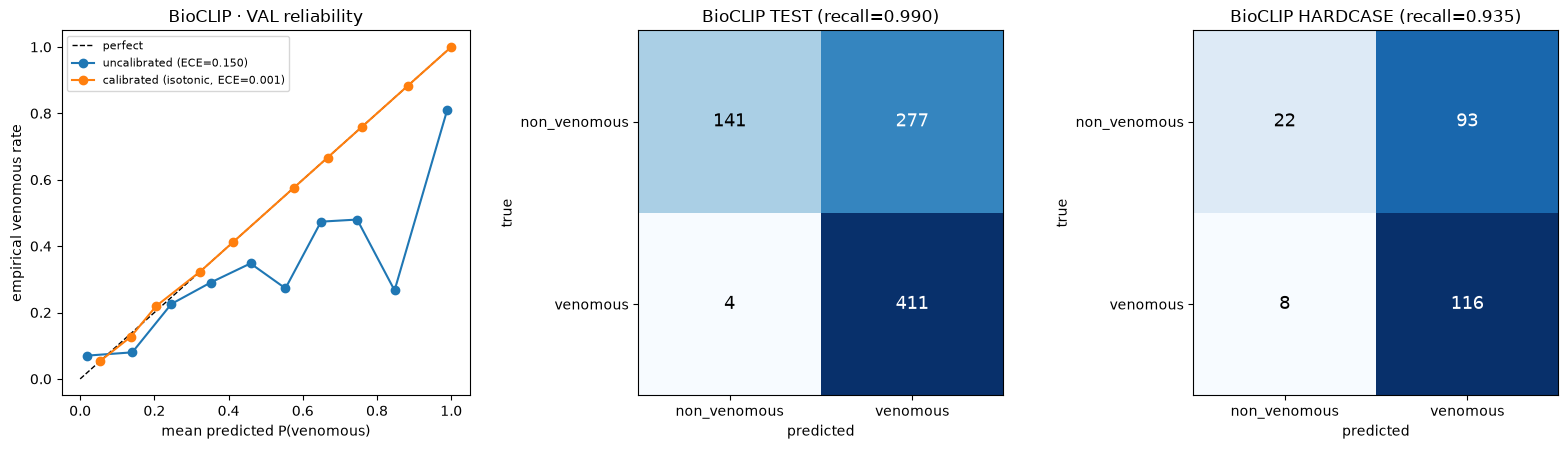

In [17]:
# --- BioCLIP: reliability (pre vs post calibration) + confusion matrices. ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
reliability_curve(ax, res_bio.y_val, res_bio.p_val_uncal, CFG.ece_bins,
                  f"uncalibrated (ECE={res_bio.val_ece_uncal:.3f})")
reliability_curve(ax, res_bio.y_val, res_bio.p_val_cal, CFG.ece_bins,
                  f"calibrated ({res_bio.cal_method}, ECE={res_bio.val_ece_cal:.3f})")
ax.set_xlabel("mean predicted P(venomous)"); ax.set_ylabel("empirical venomous rate")
ax.set_title("BioCLIP · VAL reliability"); ax.legend(fontsize=8)
plot_confusion(axes[1], res_bio.cm_test, f"BioCLIP TEST (recall={res_bio.m_test.venomous_recall:.3f})")
plot_confusion(axes[2], res_bio.cm_hard, f"BioCLIP HARDCASE (recall={res_bio.m_hard.venomous_recall:.3f})")
plt.tight_layout(); plt.show()

In [18]:
# --- BioCLIP: honest dangerous->safe miss enumeration (full counts + sample tables). ---
print(f"BioCLIP dangerous->safe misses  TEST={len(res_bio.miss_test)}  HARDCASE={len(res_bio.miss_hard)}")
print("\n--- BioCLIP TEST misses (sorted by calibrated P[venom] desc) ---")
print(res_bio.miss_test.head(15).to_string(index=False) if len(res_bio.miss_test) else "  (none)")
print("\n--- BioCLIP HARDCASE misses ---")
print(res_bio.miss_hard.head(15).to_string(index=False) if len(res_bio.miss_hard) else "  (none)")

BioCLIP dangerous->safe misses  TEST=4  HARDCASE=8

--- BioCLIP TEST misses (sorted by calibrated P[venom] desc) ---
                                                                                                                                                                  path            species               source split  venomous_prob
                                                                  e:\Coding_Notes\Faunari\data\raw\github_indian_snakes\Venomous\Russell's Viper\maxresdefault_001.jpg    Russell's Viper github_indian_snakes  test       0.070588
                                                                                                            e:\Coding_Notes\Faunari\data\raw\inaturalist\368362729.jpg Bungarus fasciatus          inaturalist  test       0.044444
e:\Coding_Notes\Faunari\data\raw\github_indian_snakes\Venomous\King Cobra\villagers-in-a-drought-hit-region-of-india-let-a-king-cobra-drink-from-a-bottle-of-water.jpg         King Cobra github_indian

### 5b · Run EfficientNetV2-S — calibrate, tune, evaluate (test + hardcase)

In [19]:
res_eff = run_backbone(EFFNET, X_eff, idx_eff, CFG)
report_backbone(res_eff, CFG)

########################################################################
# EfficientNetV2-S (ImageNet, 384px)
########################################################################
feature variant chosen (by val PR-AUC): L2-normalized
  val PR-AUC  no-L2=0.923  L2=0.926
calibration method (by val ECE): isotonic  (eces: {sigmoid=0.033, isotonic=0.000})
VAL ECE  uncalibrated=0.105 -> calibrated=0.000
calibrated threshold (tuned on VAL): 0.0851   [rule: recall>=0.98 reached; max-precision among those]

=== TEST (n=833) ===
  >> VENOMOUS RECALL (headline): 0.969  -> gate MISS
     balanced accuracy        : 0.739
     venomous precision       : 0.662
     PR-AUC (venomous)        : 0.933
     ECE (calibrated)         : 0.033
     confusion [tn=213 fp=205 | fn=13 tp=402]
     dangerous->safe MISSES (FN): 13  <-- the safety-critical errors

=== HARDCASE (n=239) ===
  >> VENOMOUS RECALL (headline): 0.839  -> gate MISS
     balanced accuracy        : 0.598
     venomous precision       : 0.5

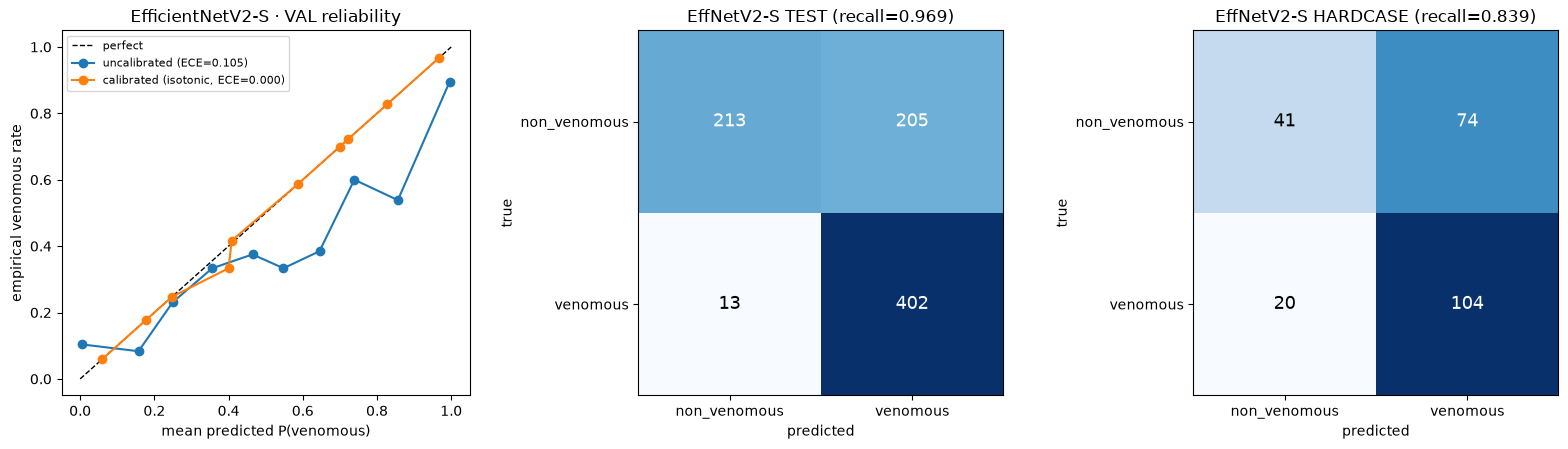

In [20]:
# --- EfficientNetV2-S: reliability (pre vs post) + confusion matrices. ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
reliability_curve(ax, res_eff.y_val, res_eff.p_val_uncal, CFG.ece_bins,
                  f"uncalibrated (ECE={res_eff.val_ece_uncal:.3f})")
reliability_curve(ax, res_eff.y_val, res_eff.p_val_cal, CFG.ece_bins,
                  f"calibrated ({res_eff.cal_method}, ECE={res_eff.val_ece_cal:.3f})")
ax.set_xlabel("mean predicted P(venomous)"); ax.set_ylabel("empirical venomous rate")
ax.set_title("EfficientNetV2-S · VAL reliability"); ax.legend(fontsize=8)
plot_confusion(axes[1], res_eff.cm_test, f"EffNetV2-S TEST (recall={res_eff.m_test.venomous_recall:.3f})")
plot_confusion(axes[2], res_eff.cm_hard, f"EffNetV2-S HARDCASE (recall={res_eff.m_hard.venomous_recall:.3f})")
plt.tight_layout(); plt.show()

In [21]:
# --- EfficientNetV2-S: honest dangerous->safe miss enumeration. ---
print(f"EffNetV2-S dangerous->safe misses  TEST={len(res_eff.miss_test)}  HARDCASE={len(res_eff.miss_hard)}")
print("\n--- EffNetV2-S TEST misses (sorted by calibrated P[venom] desc) ---")
print(res_eff.miss_test.head(15).to_string(index=False) if len(res_eff.miss_test) else "  (none)")
print("\n--- EffNetV2-S HARDCASE misses ---")
print(res_eff.miss_hard.head(15).to_string(index=False) if len(res_eff.miss_hard) else "  (none)")

EffNetV2-S dangerous->safe misses  TEST=13  HARDCASE=20

--- EffNetV2-S TEST misses (sorted by calibrated P[venom] desc) ---
                                                                                                                                                                                    path                     species       source split  venomous_prob
                                                                                                                              e:\Coding_Notes\Faunari\data\raw\inaturalist\371138922.jpg                   Naja naja  inaturalist  test       0.085106
                                                                                                                              e:\Coding_Notes\Faunari\data\raw\inaturalist\364569225.jpg                   Naja naja  inaturalist  test       0.046875
                                                                                                                              e:\Codin

### 5c · Thumbnails of dangerous→safe misses (visual sanity check)

A few of the highest-probability misses for each backbone on the hardest split (`hardcase`) — what
do the deadly errors look like? (If a backbone has zero hardcase misses, nothing is shown for it.)

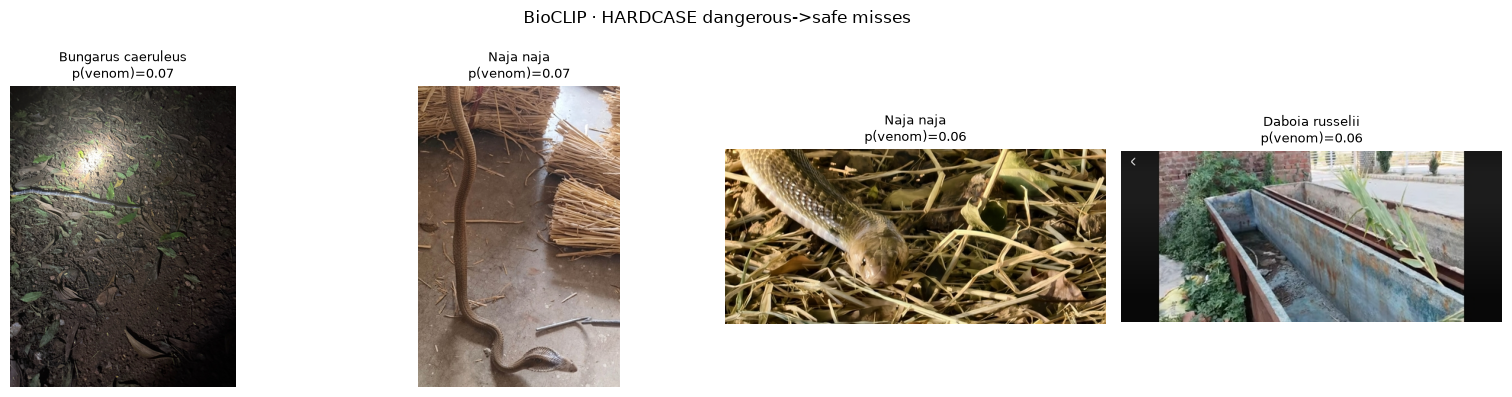

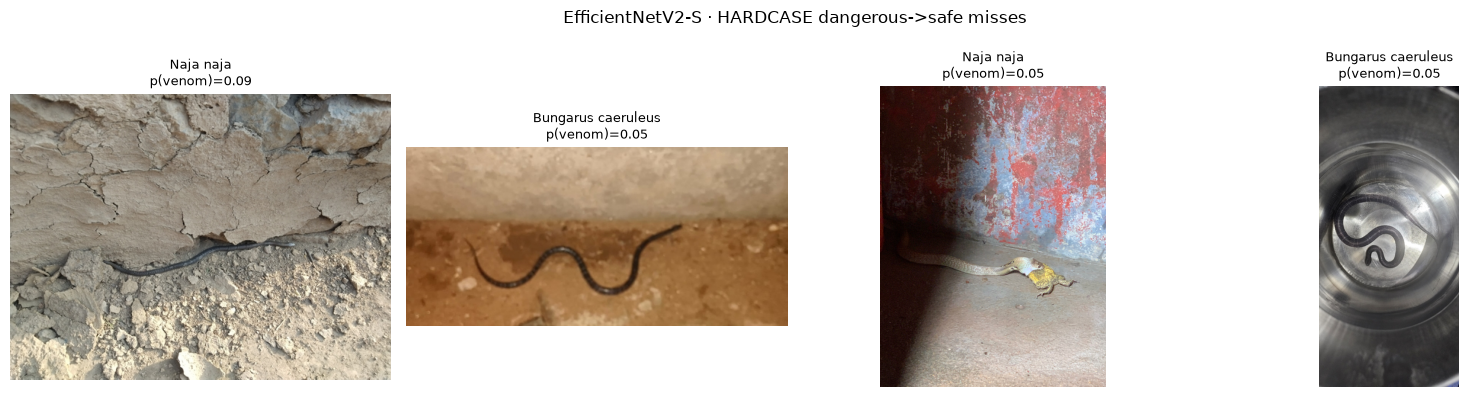

In [22]:
def show_miss_thumbnails(miss: pd.DataFrame, title: str, n: int = 4) -> None:
    """Render up to n missed images as thumbnails (visual sanity check of the deadly errors)."""
    sub = miss.head(n)
    if len(sub) == 0:
        print(f"{title}: no dangerous->safe misses to show.")
        return
    fig, axes = plt.subplots(1, len(sub), figsize=(4 * len(sub), 4))
    if len(sub) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, sub.iterrows()):
        try:
            with Image.open(r["path"]) as im:
                ax.imshow(im.convert("RGB"))
        except (UnidentifiedImageError, OSError, ValueError):
            ax.text(0.5, 0.5, "unreadable", ha="center", va="center")
        ax.set_title(f"{r['species']}\np(venom)={r['venomous_prob']:.2f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()


show_miss_thumbnails(res_bio.miss_hard, "BioCLIP · HARDCASE dangerous->safe misses", n=4)
show_miss_thumbnails(res_eff.miss_hard, "EfficientNetV2-S · HARDCASE dangerous->safe misses", n=4)

## 6 · Comparison vs nb-04 + verdict

We recompute the **nb-04 MobileNetV3-L baseline** here cheaply (the embedding cache from nb-04
exists), so balanced-acc / PR-AUC are directly comparable. We re-apply nb-04's recipe exactly:
cost-sensitive probe (no calibration, no L2-norm — as in nb-04), threshold tuned on val. Its known
headline numbers were **venomous recall test = 0.969 / hardcase = 0.871**; if our recompute differs
materially we cite the nb-04 figures and say so.

In [23]:
def recompute_nb04_baseline(cfg: Config) -> dict | None:
    """Refit nb-04's exact recipe on its cached MobileNetV3-L embeddings (no calibration/L2).

    Returns a dict of test/hardcase metrics, or None if the nb-04 cache is missing (then we cite
    the known nb-04 figures). nb-04 tuned the threshold on UNCALIBRATED val scores -> replicate.
    """
    npy = PROCESSED_DIR / "embeddings_mobilenet_v3_large.npy"
    idxp = PROCESSED_DIR / "embeddings_mobilenet_v3_large_index.csv"
    if not (npy.exists() and idxp.exists()):
        print("[nb-04] MobileNet cache not found -> citing known nb-04 figures.")
        return None
    Xm = np.load(npy).astype(np.float32)
    idxm = pd.read_csv(idxp)
    X_tr, y_tr, _ = split_xy(Xm, idxm, "train", cfg.positive_class)
    X_val, y_val, _ = split_xy(Xm, idxm, "val", cfg.positive_class)
    X_te, y_te, _ = split_xy(Xm, idxm, "test", cfg.positive_class)
    X_hc, y_hc, _ = split_xy(Xm, idxm, "hardcase", cfg.positive_class)
    pipe = build_probe(cfg, l2norm=False).fit(X_tr, y_tr)            # nb-04 = no L2-norm.
    s_val = pipe.predict_proba(X_val)[:, 1]                          # nb-04 = uncalibrated scores.
    thr, _ = tune_threshold(y_val, s_val, cfg.target_recall, cfg.precision_floor)
    s_te = pipe.predict_proba(X_te)[:, 1]
    s_hc = pipe.predict_proba(X_hc)[:, 1]
    m_te, _ = evaluate_split("test", y_te, s_te, thr, cfg.ece_bins)
    m_hc, _ = evaluate_split("hardcase", y_hc, s_hc, thr, cfg.ece_bins)
    print(f"[nb-04] recomputed (threshold={thr:.4f}): "
          f"venom recall test={m_te.venomous_recall:.3f} hardcase={m_hc.venomous_recall:.3f}")
    return {"m_test": m_te, "m_hard": m_hc, "threshold": thr}


nb04 = recompute_nb04_baseline(CFG)

[nb-04] recomputed (threshold=0.0000): venom recall test=0.969 hardcase=0.871


In [24]:
def gate_str(recall_test: float, recall_hard: float, gate: float) -> str:
    """PASS only if BOTH splits clear the gate, else which split(s) missed."""
    ok_t, ok_h = recall_test >= gate, recall_hard >= gate
    if ok_t and ok_h:
        return "PASS"
    missed = [s for s, ok in (("test", ok_t), ("hardcase", ok_h)) if not ok]
    return "MISS (" + ",".join(missed) + ")"


def comparison_row(name: str, m_test: SplitMetrics, m_hard: SplitMetrics, gate: float) -> dict:
    """One model's row for the comparison table (venomous recall is the headline)."""
    return {
        "model": name,
        "recall_test": round(m_test.venomous_recall, 3),
        "recall_hardcase": round(m_hard.venomous_recall, 3),
        "balacc_test": round(m_test.balanced_accuracy, 3),
        "balacc_hardcase": round(m_hard.balanced_accuracy, 3),
        "prauc_test": round(m_test.pr_auc, 3),
        "prauc_hardcase": round(m_hard.pr_auc, 3),
        "gate": gate_str(m_test.venomous_recall, m_hard.venomous_recall, gate),
    }


rows: list[dict] = []
if nb04 is not None:
    rows.append(comparison_row("nb-04 MobileNetV3-L (frozen, uncalibrated)",
                               nb04["m_test"], nb04["m_hard"], CFG.gate))
else:  # cite the known nb-04 figures if the cache was missing.
    rows.append({"model": "nb-04 MobileNetV3-L (cited)", "recall_test": 0.969,
                 "recall_hardcase": 0.871, "balacc_test": np.nan, "balacc_hardcase": np.nan,
                 "prauc_test": np.nan, "prauc_hardcase": np.nan,
                 "gate": gate_str(0.969, 0.871, CFG.gate)})

bio_name = "BioCLIP" + (" [FELL BACK TO CLIP ViT-B/16]" if BIOCLIP_FELL_BACK else "")
rows.append(comparison_row(bio_name + " (frozen, calibrated)", res_bio.m_test, res_bio.m_hard, CFG.gate))
rows.append(comparison_row("EfficientNetV2-S (frozen, calibrated)", res_eff.m_test, res_eff.m_hard, CFG.gate))

comparison = pd.DataFrame(rows)[
    ["model", "recall_test", "recall_hardcase", "balacc_test", "balacc_hardcase",
     "prauc_test", "prauc_hardcase", "gate"]]
print("=" * 100)
print("COMPARISON — venomous recall is the headline; gate = recall >= {:.2f} on BOTH splits".format(CFG.gate))
print("=" * 100)
print(comparison.to_string(index=False))

COMPARISON — venomous recall is the headline; gate = recall >= 0.98 on BOTH splits
                                     model  recall_test  recall_hardcase  balacc_test  balacc_hardcase  prauc_test  prauc_hardcase                 gate
nb-04 MobileNetV3-L (frozen, uncalibrated)        0.969            0.871        0.569            0.527       0.821           0.688 MISS (test,hardcase)
              BioCLIP (frozen, calibrated)        0.990            0.935        0.664            0.563       0.906           0.768      MISS (hardcase)
     EfficientNetV2-S (frozen, calibrated)        0.969            0.839        0.739            0.598       0.933           0.774 MISS (test,hardcase)


In [25]:
# --- Pick the winner (best hardcase venomous recall, tie-break on test) and state the verdict. ---
candidates = [
    ("BioCLIP", res_bio),
    ("EfficientNetV2-S", res_eff),
]
winner_name, winner = max(
    candidates, key=lambda kv: (kv[1].m_hard.venomous_recall, kv[1].m_test.venomous_recall))

both_pass = (winner.m_test.venomous_recall >= CFG.gate and
             winner.m_hard.venomous_recall >= CFG.gate)

print(f"WINNER (best hardcase venomous recall): {winner_name}")
print(f"  test recall={winner.m_test.venomous_recall:.3f} | hardcase recall={winner.m_hard.venomous_recall:.3f}")
print()
if both_pass:
    print("VERDICT: Stronger frozen features + calibration CLOSE the gap — the winner clears the "
          "0.98 gate on BOTH test and hardcase. Frozen features are sufficient for Phase-1.")
else:
    gap_hc = CFG.gate - winner.m_hard.venomous_recall
    gap_te = CFG.gate - winner.m_test.venomous_recall
    worst = "hardcase" if winner.m_hard.venomous_recall < winner.m_test.venomous_recall else "test"
    print(f"VERDICT: Stronger frozen features + calibration NARROW the gap but do NOT clear the 0.98 "
          f"gate (worst split: {worst}; remaining gap test={max(gap_te,0):.3f}, hardcase={max(gap_hc,0):.3f}). "
          f"Fine-tuning the backbone and/or more venomous look-alike data is needed for Phase-1.")

WINNER (best hardcase venomous recall): BioCLIP
  test recall=0.990 | hardcase recall=0.935

VERDICT: Stronger frozen features + calibration NARROW the gap but do NOT clear the 0.98 gate (worst split: hardcase; remaining gap test=0.000, hardcase=0.045). Fine-tuning the backbone and/or more venomous look-alike data is needed for Phase-1.


## Findings & next steps

> The numbers printed by the cells above are the source of truth; this cell only frames them.

**What changed vs nb-04**
- **Backbones:** generic ImageNet MobileNet → **BioCLIP** (biology prior) and **EfficientNetV2-S**
  (stronger generic CNN at 384px), both **frozen** (no backprop through the CNN).
- **Calibration:** added `CalibratedClassifierCV` fit on **val** (FrozenEstimator path for sklearn
  1.9). The calibrated threshold printed above is a **sane probability**, not ~0 — the core fix for
  nb-04's degenerate operating point.
- **L2-norm:** decided **per backbone by val PR-AUC** (cosine-style features for CLIP).

**Read the result from the comparison table + gate check + verdict cells:**
- Winner = highest **hardcase** venomous recall (the real stress test: rat↔cobra, wolf↔krait).
- Gate = venomous recall ≥ **0.98** on **BOTH** test and hardcase.

**If the gate is still missed (likely on hardcase):** the most probable next levers — *fine-tune* the
backbone (now warranted, since frozen features have been pushed hard), add targeted licensed
**venomous look-alike** images (krait / wolf-snake), and get herpetologist sign-off on the flagged
miss images above. Calibration is now in place for an explicit cost-based threshold post-fine-tune.